In [1]:
from utils import get_gsm8k_df
from statistical_significance import compare_accuracies, compare_accuracies_v2, compare_accuracies_v3
import numpy as np
df = get_gsm8k_df("Direct Prompting")

gemma-3-27b-it.xlsx
qwen3_1.7b.xlsx
smollm2_360m.xlsx
qwen2-math_1.5b.xlsx
qwen3_0.6b.xlsx
qwen2.5_0.5b.xlsx
gemma3_1b.xlsx
deepseek-r1_1.5b.xlsx
llama3.2_1b.xlsx


# Misclassified

In [4]:
df_misc = get_gsm8k_df("Direct Prompting", include_misclassified=True)
df_misc = df_misc[df_misc["Error Type"] == "Misclassified"]
df_misc.groupby(["Model", "Error Class"]).agg({
    "question": "count",
}).reset_index().sort_values(by="question", ascending=False).head(50)

gemma-3-27b-it.xlsx
qwen3_1.7b.xlsx
smollm2_360m.xlsx
qwen2-math_1.5b.xlsx
qwen3_0.6b.xlsx
qwen2.5_0.5b.xlsx
gemma3_1b.xlsx
deepseek-r1_1.5b.xlsx
llama3.2_1b.xlsx


,Model,Error Class,question
1,ollama/deepseek-r1_1.5b,Misclassified,16
3,ollama/qwen2-math_1.5b,Misclassified,8
4,ollama/qwen2.5_0.5b,Misclassified,6
2,ollama/llama3.2_1b,Misclassified,5
0,google/gemma-3-27b-it,Misclassified,3
5,ollama/qwen3_1.7b,Misclassified,3
6,ollama/smollm2_360m,Misclassified,2


In [5]:
overall_misc_rate = len(df_misc) / len(df)
print(f"Total misclassified examples: {len(df_misc)}")
print(f"Total examples: {len(df)}")
print(f"Overall misclassification rate: {overall_misc_rate:.2%}")

Total misclassified examples: 43
Total examples: 2700
Overall misclassification rate: 1.59%


# Accuracy

## Sorted

In [2]:
df_acc = df.groupby(["Model"]).agg({
    "is_correct": "mean",
}).reset_index().sort_values(by="is_correct", ascending=False)
df_acc

,Model,is_correct
0,google/gemma-3-27b-it,0.973333
4,ollama/qwen2-math_1.5b,0.823333
1,ollama/deepseek-r1_1.5b,0.733333
7,ollama/qwen3_1.7b,0.666667
6,ollama/qwen3_0.6b,0.610000
2,ollama/gemma3_1b,0.586667
3,ollama/llama3.2_1b,0.506667
5,ollama/qwen2.5_0.5b,0.403333
8,ollama/smollm2_360m,0.053333


## Alphabetical

In [7]:
df_acc = df.groupby(["Model"]).agg({
    "is_correct": "mean",
}).reset_index().sort_values(by="Model", ascending=True)
df_acc

,Model,is_correct
0,google/gemma-3-27b-it,0.973333
1,ollama/deepseek-r1_1.5b,0.733333
2,ollama/gemma3_1b,0.586667
3,ollama/llama3.2_1b,0.506667
4,ollama/qwen2-math_1.5b,0.823333
5,ollama/qwen2.5_0.5b,0.403333
6,ollama/qwen3_0.6b,0.610000
7,ollama/qwen3_1.7b,0.666667
8,ollama/smollm2_360m,0.053333


# Error Analysis

## Overview

In [8]:
df_err = df.groupby(["Model", "Error Type", "Error Class"]).agg({
    "question": "count",
}).pivot_table(
    index=["Model"],
    columns=["Error Type", "Error Class"],
    values="question",
    fill_value=0
).reset_index()

df_err.head(50)

Error Type                     Model   Execution Error                     \
Error Class                          Calculation Error  Loop Overthinking   
0              google/gemma-3-27b-it               0.0   0.0          0.0   
1            ollama/deepseek-r1_1.5b               0.0   0.0          9.0   
2                   ollama/gemma3_1b               0.0  41.0          0.0   
3                 ollama/llama3.2_1b               4.0   1.0          0.0   
4             ollama/qwen2-math_1.5b               0.0   0.0          0.0   
5                ollama/qwen2.5_0.5b               1.0   2.0          0.0   
6                  ollama/qwen3_0.6b               0.0  11.0         67.0   
7                  ollama/qwen3_1.7b               0.0   2.0         77.0   
8                ollama/smollm2_360m               1.0   3.0          0.0   

Error Type                                  
Error Class Too Few Tokens Wrong Reasoning  
0                      0.0             8.0  
1                      2.0            69.0  
2                      0.0            83.0  
3                      0.0           142.0  
4                      0.0            53.0  
5                      0.0           176.0  
6                      5.0            34.0  
7                     19.0             2.0  
8                      0.0           280.0

## Plots

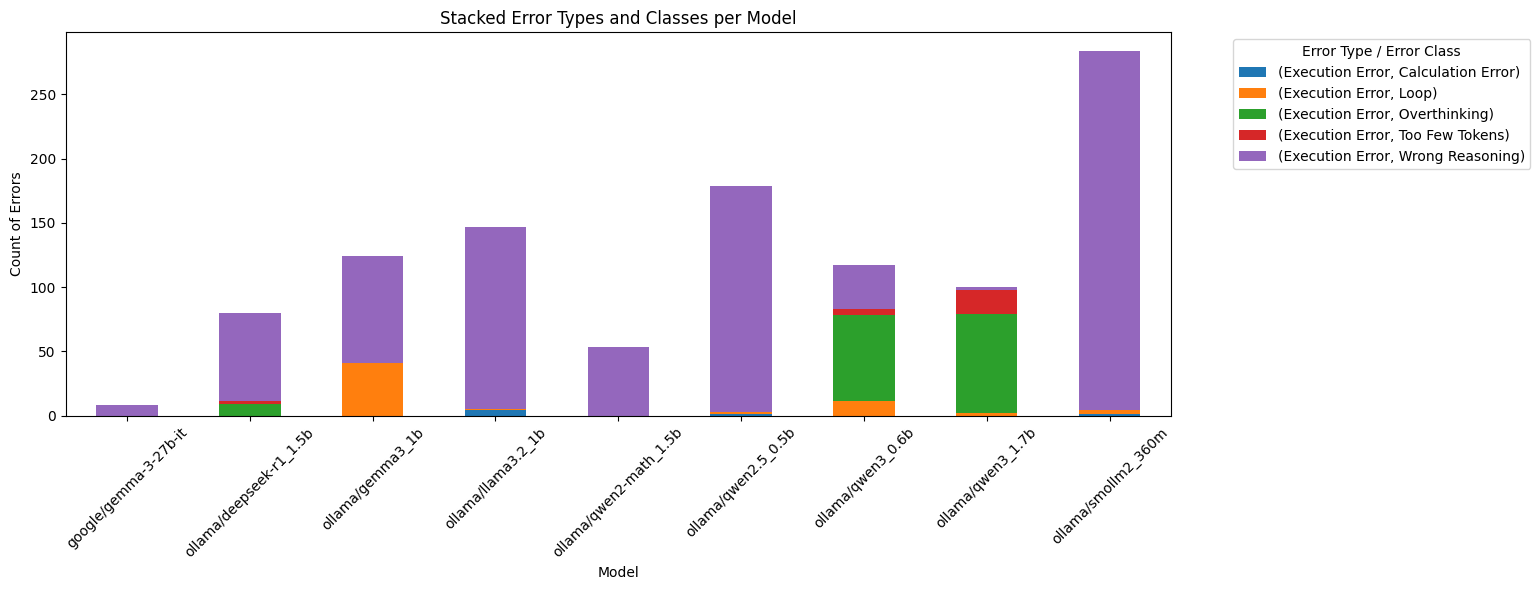

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Set index to "Model" to prepare for plotting
df_plot = df_err.set_index("Model")

# Plot as stacked bar chart
df_plot.plot(kind="bar", stacked=True, figsize=(12, 6))

plt.ylabel("Count of Errors")
plt.title("Stacked Error Types and Classes per Model")
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend(title="Error Type / Error Class", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## Question Type

In [22]:
# Different question types
def classify_question_type(question):
    if "how many" in question.lower():
        return "How Many"
    elif "how much" in question.lower():
        return "How Much"
    elif "what" in question.lower():
        return "What"
    elif "calculate" in question.lower():
        return "Calculate"
    elif "how" in question.lower():
        return "How"
    return np.nan

df_qt = df.copy()
df_qt['Question_Type'] = df['question'].apply(classify_question_type)
print("NAN Question Types:", df_qt['Question_Type'].isna().sum())

# show ten questions with NaN question types
for question in df_qt[df_qt['Question_Type'].isna()]['question']:
    print(question)

# Filter df by unique ids and collect number of unique question types
def get_question_type_mapping():
    seen_ids = set()
    question_type_mapping = {}
    for _, row in df_qt.iterrows():
        if row['question'] not in seen_ids:
            seen_ids.add(row['question'])
            if row['Question_Type'] not in question_type_mapping:
                question_type_mapping[row['Question_Type']] = 0
            question_type_mapping[row['Question_Type']] += 1
    return question_type_mapping

question_type_mapping = get_question_type_mapping()

question_type_df = pd.DataFrame(list(question_type_mapping.items()), columns=['Question Type', 'Count'])
question_type_df = question_type_df.sort_values(by='Count', ascending=False)
question_type_df

NAN Question Types: 0


,Question Type,Count
1,How Many,166
0,How Much,76
3,What,29
2,How,15
4,Calculate,14


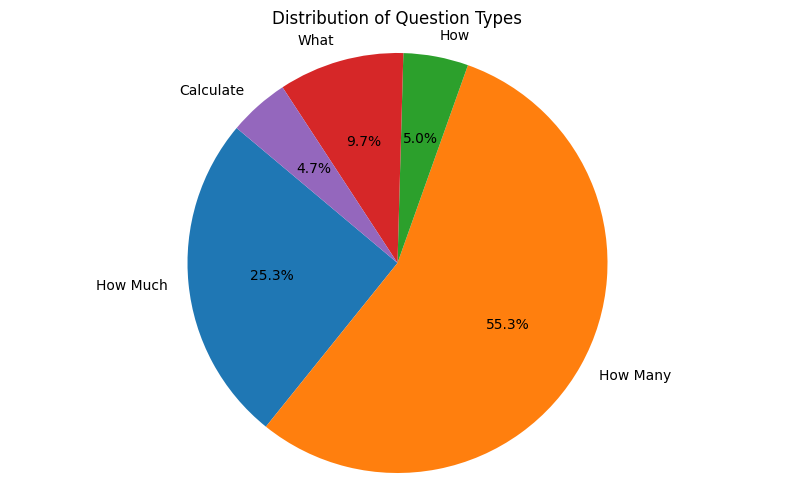

In [23]:
# Make a pie chart of the question types
import matplotlib.pyplot as plt
question_types = list(question_type_mapping.keys())
question_counts = list(question_type_mapping.values())
plt.figure(figsize=(10, 6))
plt.pie(question_counts, labels=question_types, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Question Types')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

In [24]:
qtypes_df = df_qt.groupby(["Model", "Question_Type"]).agg({
    "is_correct": "sum"
}).reset_index()

qtypes_df["Total_Questions"] = qtypes_df["Question_Type"].map(lambda x: question_type_mapping.get(x, 0))
qtypes_df["Correct_Score"] = qtypes_df["is_correct"] / qtypes_df["Total_Questions"] * 100
qtypes_pivot = qtypes_df.pivot_table(index='Question_Type', columns='Model', values='Correct_Score', fill_value=0)
qtypes_pivot

Model,google/gemma-3-27b-it,ollama/deepseek-r1_1.5b,ollama/gemma3_1b,ollama/llama3.2_1b,ollama/qwen2-math_1.5b,ollama/qwen2.5_0.5b,ollama/qwen3_0.6b,ollama/qwen3_1.7b,ollama/smollm2_360m
Question_Type,,,,,,,,,
Calculate,100.000000,78.571429,85.714286,50.000000,100.000000,57.142857,85.714286,85.714286,0.000000
How,100.000000,60.000000,46.666667,40.000000,66.666667,26.666667,53.333333,46.666667,0.000000
How Many,97.590361,74.698795,63.855422,51.204819,86.746988,42.771084,61.445783,69.879518,4.819277
How Much,96.052632,71.052632,46.052632,55.263158,73.684211,36.842105,55.263158,61.842105,9.210526
What,96.551724,75.862069,55.172414,41.379310,79.310345,34.482759,65.517241,62.068966,3.448276


In [25]:
qtypes_dict = qtypes_pivot.to_dict()
significant_results = {}
for model, scores in qtypes_dict.items():
    items = list(scores.items())
    significant_results[model] = []
    for i in range(len(items)):
        for j in range(i + 1, len(items)):
            item1, item2 = items[i], items[j]
            p1 = item1[1]/100
            p2 = item2[1]/100
            n1 = question_type_mapping.get(item1[0], 0)
            n2 = question_type_mapping.get(item2[0], 0)
            
            if n1 == 0 or n2 == 0:
                raise ValueError(f"Question type '{item1[0]}' or '{item2[0]}' not found in mapping.")
            result = compare_accuracies_v3(p1, n1, p2, n2)
            if result.is_significant:
                significant_results[model].append((item1[0], item1[1], item2[0], item2[1], result.p_value, result.is_significant))
                print(f"Comparing {p1} (n={n1}) with {p2} (n={n2}) for model {model}")

significant_results_df = pd.DataFrame([
    {
        'Model': model,
        'Type1': item[0],
        'Score1': item[1],
        'Type2': item[2],
        'Score2': item[3],
        'p_value': item[4],
        'is_significant': item[5]
    }
    for model, items in significant_results.items()
    for item in items
])
significant_results_df.head(10)

Comparing 0.8571428571428571 (n=14) with 0.4605263157894737 (n=76) for model ollama/gemma3_1b
Comparing 0.6385542168674698 (n=166) with 0.4605263157894737 (n=76) for model ollama/gemma3_1b
Comparing 1.0 (n=14) with 0.6666666666666665 (n=15) for model ollama/qwen2-math_1.5b
Comparing 1.0 (n=14) with 0.7368421052631579 (n=76) for model ollama/qwen2-math_1.5b
Comparing 0.8674698795180723 (n=166) with 0.7368421052631579 (n=76) for model ollama/qwen2-math_1.5b
Comparing 0.8571428571428571 (n=14) with 0.5526315789473685 (n=76) for model ollama/qwen3_0.6b


,Model,Type1,Score1,Type2,Score2,p_value,is_significant
0,ollama/gemma3_1b,Calculate,85.714286,How Much,46.052632,0.007961,True
1,ollama/gemma3_1b,How Many,63.855422,How Much,46.052632,0.009104,True
2,ollama/qwen2-math_1.5b,Calculate,100.000000,How,66.666667,0.042146,True
3,ollama/qwen2-math_1.5b,Calculate,100.000000,How Much,73.684211,0.033734,True
4,ollama/qwen2-math_1.5b,How Many,86.746988,How Much,73.684211,0.021819,True
5,ollama/qwen3_0.6b,Calculate,85.714286,How Much,55.263158,0.039436,True


Interpretation

- **Gemma3 1b**: Performs better on *calcualte* and *how many* than on *how much*
- **Math 1.5b**: Performs significantly better on *calculate* than on *how much* and *how* questions. *How many* is also better than *how much*
- **Qwen3 0.6b**: performs significantly better on *calculate* than on *how much*

**Conclusion**: Phrase questions with *calculate* specific things to improve performance for some models
